<a href="https://colab.research.google.com/github/AydanTrawick/Pytorch-Tut/blob/main/IrisNeuralNetwork.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

print("Imports ready to go")

Imports ready to go


In [2]:
# Create a Model Class that inherits nn.Module

class Model(nn.Module):
  # Input layer (4 features of the flower) -->
  # Hidden Layer1 (number of neurons) -->
  # H2(n) -->
  # output (3 classes of iris flowers)
  def __init__(self, in_features=4, h1=8, h2=9, out_features=3):
    super().__init__() #instatiates our nn.Model
    self.fc1= nn.Linear(in_features, h1)
    self.fc2= nn.Linear(h1, h2)
    self.out= nn.Linear(h2, out_features)

  def forward(self, x):
  # rectified linear unit. If the output is less than 0 we will just call it zero
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = self.out(x)


    return x




In [3]:
# Pick a manual seed for randomization
torch.manual_seed(41)
# Create an instance of our model
model= Model()

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [5]:
url = 'https://gist.githubusercontent.com/netj/8836201/raw/6f9306ad21398ea43cba4f7d537619d0e07d5ae3/iris.csv'
my_df = pd.read_csv(url)

my_df

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Virginica
146,6.3,2.5,5.0,1.9,Virginica
147,6.5,3.0,5.2,2.0,Virginica
148,6.2,3.4,5.4,2.3,Virginica


In [6]:
# Changing the variety column to number values

my_df['variety'] = my_df['variety'].replace('Setosa', 0.0)
my_df['variety'] = my_df['variety'].replace('Virginica', 1.0)
my_df['variety'] = my_df['variety'].replace('Versicolor', 2.0)

my_df

/tmp/ipykernel_2872/3809099413.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  my_df['variety'] = my_df['variety'].replace('Versicolor', 2.0)


,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0
3,4.6,3.1,1.5,0.2,0.0
4,5.0,3.6,1.4,0.2,0.0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,1.0
146,6.3,2.5,5.0,1.9,1.0
147,6.5,3.0,5.2,2.0,1.0
148,6.2,3.4,5.4,2.3,1.0


In [7]:
# Train test split Set X,y

X = my_df.drop('variety', axis=1)
y= my_df['variety']


In [8]:
# Convert these to numpy arrays

X= X.values
y= y.values

In [9]:
from sklearn.model_selection import train_test_split

In [10]:
# Train test split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state=41)

In [11]:
# Convert X features to float tensors

X_train= torch.FloatTensor(X_train)
X_test= torch.FloatTensor(X_test)

In [12]:
# Convert y features to tensors long

y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)

In [13]:
# Set the criterion of model to measure the error, how far off the predictions are from the data

criterion= nn.CrossEntropyLoss()

# Choose an optimizer(Adams Optimizer), lr= learning rate(if error doesnt go down after a bunch of iterations we want to lower out lr)

optimizer= torch.optim.Adam(model.parameters(), lr= 0.01)

In [14]:
# Train our model
# Epochs? (One run through all the layers in our NN)

epochs = 100
losses = []

for i in range(epochs):
  # Go forward and get a prediction
  y_pred = model.forward(X_train) # Get predicted results

  # Measure the loss/error

  loss= criterion(y_pred, y_train) #predicted value vs the training values

  # Keep track of losses
  losses.append(loss.detach().numpy())


  # PRINT EVERY 10 EPOCHS
  if i % 10 == 0:
    print(f"Epoch: {i} and loss: {loss}")

# Do some back propagation: tajke the error rate of forward propogation and
# feed it back thriugh the network to fine tune the weights

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

Epoch: 0 and loss: 1.1397501230239868
Epoch: 10 and loss: 1.0544780492782593
Epoch: 20 and loss: 0.9169962406158447
Epoch: 30 and loss: 0.6265316605567932
Epoch: 40 and loss: 0.3989596962928772
Epoch: 50 and loss: 0.248995840549469
Epoch: 60 and loss: 0.13557122647762299
Epoch: 70 and loss: 0.0753168836236
Epoch: 80 and loss: 0.05017305538058281
Epoch: 90 and loss: 0.03872577100992203


Text(0.5, 0, 'Epoch')

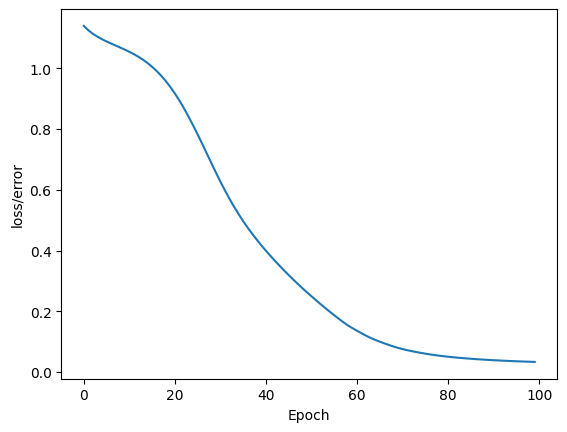

In [15]:
# Graph it out

plt.plot(range(epochs), losses)
plt.ylabel("loss/error")
plt.xlabel("Epoch")

In [16]:
# Evaluate Model on Test data set
with torch.no_grad():  #Basically turn off back propogation
  y_eval = model.forward(X_test) # X_test are features from our test set, y_eval will be the predictions/targets
  loss = criterion(y_eval,y_test) # Find the loss error

In [17]:
loss

tensor(0.1286)

In [18]:
correct = 0

with torch.no_grad():
  for i, data in enumerate(X_test):
    y_val = model.forward(data)

    if y_test[i] == 0:
      x = "Setosa"
    elif y_test[i] == 1:
      x = "Virginica"
    else:
      x = "Versicolor"

    # Will tell us ehat type of flower class our network thinks it is

    print(f'{i+1}.)  {str(y_val)} \t {x} \t {y_val.argmax().item()}')

    #Correct or not

    if y_val.argmax().item() == y_test[i]:
      correct += 1

    print(f"We got {correct} correct!")

1.)  tensor([-6.9784,  5.7408,  2.8402]) 	 Virginica 	 1
We got 1 correct!
2.)  tensor([-10.1071,   9.1282,   1.2868]) 	 Virginica 	 1
We got 2 correct!
3.)  tensor([-10.9573,   9.6341,   2.1394]) 	 Virginica 	 1
We got 3 correct!
4.)  tensor([-2.8619,  1.0350,  5.6483]) 	 Versicolor 	 2
We got 4 correct!
5.)  tensor([-8.7825,  7.4768,  2.6113]) 	 Virginica 	 1
We got 5 correct!
6.)  tensor([-0.5755, -1.5204,  7.0309]) 	 Versicolor 	 2
We got 6 correct!
7.)  tensor([-6.4483,  4.9982,  3.6193]) 	 Virginica 	 1
We got 7 correct!
8.)  tensor([-2.5482,  0.6935,  5.8083]) 	 Versicolor 	 2
We got 8 correct!
9.)  tensor([-7.5285,  6.1544,  3.1245]) 	 Virginica 	 1
We got 9 correct!
10.)  tensor([-10.7089,   9.6708,   1.3234]) 	 Virginica 	 1
We got 10 correct!
11.)  tensor([-5.9014,  4.4571,  3.7348]) 	 Virginica 	 1
We got 11 correct!
12.)  tensor([ 13.1980, -14.0947,   5.5082]) 	 Setosa 	 0
We got 12 correct!
13.)  tensor([ 12.0202, -12.7830,   4.8827]) 	 Setosa 	 0
We got 13 correct!
14.) 

In [23]:
new_iris = torch.tensor([6.5,	3.0	,5.2,	2.0])

In [25]:
with torch.no_grad():
  print(model(new_iris))

tensor([-7.5285,  6.1544,  3.1245])


In [26]:
another_tensor = torch.tensor([5.0,3.6,1.4,0.2])

with torch.no_grad():
  print(model(another_tensor))

tensor([ 13.6872, -14.4954,   5.2862])


In [27]:
# save and load or NN model

torch.save(model.state_dict(), 'My_iris_model.pt')

In [30]:
# Loading the model

new_model = Model()
new_model.load_state_dict(torch.load('My_iris_model.pt'))

<All keys matched successfully>

In [31]:
new_model.eval()

Model(
  (fc1): Linear(in_features=4, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=9, bias=True)
  (out): Linear(in_features=9, out_features=3, bias=True)
)